# CV analysis: pyrrole -25 C - 2026-05-22 17:00 (LENGTH)

Pairs the scope **length**-sensor log with the potentiostat CV log from the same run.
**Three cycles**, +1 V -> -1 V -> +1 V at **3 mV/s** (~1334 s/cycle).

- Scope: `scope_log_20260522_165959_..._LENGTH.csv` - length signal is on **CH1** (CH2 is 0).
- Potentiostat: `Potentiostat_measurements/05.22.26-neg25C_in_tissue_LENGTH_3mVpersec.csv` (3 scans).

Scope and potentiostat were started simultaneously (offset = 0 s); the potentiostat header
timestamp is ignored. The per-sample interval `DT` is derived from the recorded voltage step
and the 3 mV/s scan rate (~0.331 s/sample).

**Secondary y-axes (left panels):**
- Distance: the calibration `length = -0.4130 * V` was derived at **1x gain**, but this data was
  captured at **10x gain**, so 1 V corresponds to 1/10 the distance -> coefficient **-0.04130 mm/V**.
- Strain = distance / original length, with **L0 = 4 mm** (actuation axis).

The distance/strain axes are pure linear rescalings of the scope voltage (no baseline subtraction),
matching the reference notebook - read the *swing* across the curve as the actuation, not the absolute value.


In [1]:
# Load both files, align (offset = 0), filter scope outliers, map to applied voltage + cycle index.

import io, csv
import numpy as np
import pandas as pd

SCOPE_CSV = '/Users/yitong/Documents/GitHub/chicken_necrobots/cold_pyrrole_in_tissue_experiments_5.22.26/scope_log_20260615_170309_2Day_10%_formalin_2.5mVperSecond_LENGTH.csv'
POTEN_CSV = '/Users/yitong/Documents/GitHub/chicken_necrobots/cold_pyrrole_in_tissue_experiments_5.22.26/Potentiostat_measurements/06.15.26-2Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'
SCOPE_CHANNEL = 'ch1_MEAN_V'      # LENGTH signal is on CH1 (CH2 is 0)

SCAN_RATE_V_PER_S = 0.0025         # 2.5 mV/s
WINDOW = 41                        # MAD outlier-filter rolling window (samples)
K = 5.0                            # outlier threshold (multiples of MAD)


# ---- 1. Potentiostat (UTF-16, 6-line header, N scans side by side) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('﻿', '')

lines = text.splitlines()
rows = list(csv.reader(io.StringIO('\n'.join(lines[6:]))))
rows = [r for r in rows if r and r[0]]
n_scans = len(rows[0]) // 2                       # 2 columns (V, microA) per scan
cols = []
for s in range(n_scans):
    cols += [f'v{s+1}', f'i{s+1}_uA']
poten = pd.DataFrame([[float(x) for x in r[:2*n_scans]] for r in rows], columns=cols)
n_per_scan = len(poten)
print(f'Potentiostat: {n_scans} scans (cycles), {n_per_scan} samples/scan')


# ---- 2. Derive sample interval from the recorded voltage step + scan rate ----
# Each scan ramps +1 V -> -1 V -> +1 V at a fixed 3 mV/s. The downward leg from
# sample 0 to the argmin spans a known voltage delta, so DT = |dV| / scan_rate.
# (More robust than hard-coding 0.2 s the way the 5 mV/s reference notebook did.)
v1 = poten['v1'].values
turn_idx = int(np.argmin(v1))
DT = abs(v1[0] - v1[turn_idx]) / turn_idx / SCAN_RATE_V_PER_S
per_scan_s = n_per_scan * DT
exp_total_s = n_scans * per_scan_s
print(f'Derived DT = {DT:.4f} s/sample  ->  {per_scan_s:.1f} s/cycle, {exp_total_s:.1f} s total')

t_scan = np.arange(n_per_scan) * DT
t_exp_full = np.concatenate([t_scan + s*per_scan_s for s in range(n_scans)])
v_applied_full = np.concatenate([poten[f'v{s+1}'].values for s in range(n_scans)])


# ---- 3. Scope log + alignment (offset = 0; scope and potentiostat started together) ----
# The potentiostat header's "Date and time measurement" does not reflect the true
# acquisition-start instant, so we ignore it and assume a simultaneous start.
scope = pd.read_csv(SCOPE_CSV)
scope['t_exp'] = scope['elapsed_s']
scope_in = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= exp_total_s)].copy()
print(f'Scope rows in experiment window: {len(scope_in)} / {len(scope)} '
      f'(max elapsed {scope["elapsed_s"].max():.1f} s)')


# ---- 4. Outlier filter (rolling-median + MAD) ----
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad_floor = max(np.nanstd(x) * 1e-3, 1e-9)
    mad = mad.clip(lower=mad_floor)
    return (abs_dev > k * mad).values

mask = mark_outliers(scope_in[SCOPE_CHANNEL].values, window=WINDOW, k=K)
print(f'Flagged {mask.sum()} of {len(scope_in)} in-window scope samples '
      f'({mask.sum()/max(len(scope_in),1)*100:.2f}%) as outliers.')
scope_clean = scope_in.loc[~mask].copy()


# ---- 5. Map scope samples to applied voltage + cycle index ----
scope_clean['v_applied'] = np.interp(scope_clean['t_exp'].values, t_exp_full, v_applied_full)
scope_clean['cycle'] = np.clip((scope_clean['t_exp'].values // per_scan_s).astype(int), 0, n_scans-1)
for c in range(n_scans):
    print(f'Cycle {c+1} scope rows:', (scope_clean['cycle'] == c).sum())
scope_clean.head()


Potentiostat: 3 scans (cycles), 4034 samples/scan
Derived DT = 0.3967 s/sample  ->  1600.4 s/cycle, 4801.3 s total
Scope rows in experiment window: 9714 / 9805 (max elapsed 4844.3 s)
Flagged 221 of 9714 in-window scope samples (2.28%) as outliers.
Cycle 1 scope rows: 3134
Cycle 2 scope rows: 3167
Cycle 3 scope rows: 3192


,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,t_exp,v_applied,cycle
0,0.4869,2026-06-15T17:03:09.850523,-0.290920,0.0,0.4869,0.998796,0
1,0.9819,2026-06-15T17:03:10.345430,-0.291184,0.0,0.9819,0.997567,0
2,1.4870,2026-06-15T17:03:10.850546,-0.291008,0.0,1.4870,0.996314,0
3,1.9807,2026-06-15T17:03:11.344246,-0.291080,0.0,1.9807,0.995051,0
4,2.4767,2026-06-15T17:03:11.840284,-0.290360,0.0,2.4767,0.993859,0


Per-cycle loop-closure gap (mm), end - start of smoothed length:
  cycle 1: before = +0.00117 mm   ->   after = -0.00000 mm
  cycle 2: before = +0.00262 mm   ->   after = +0.00000 mm
  cycle 3: before = +0.00247 mm   ->   after = +0.00000 mm


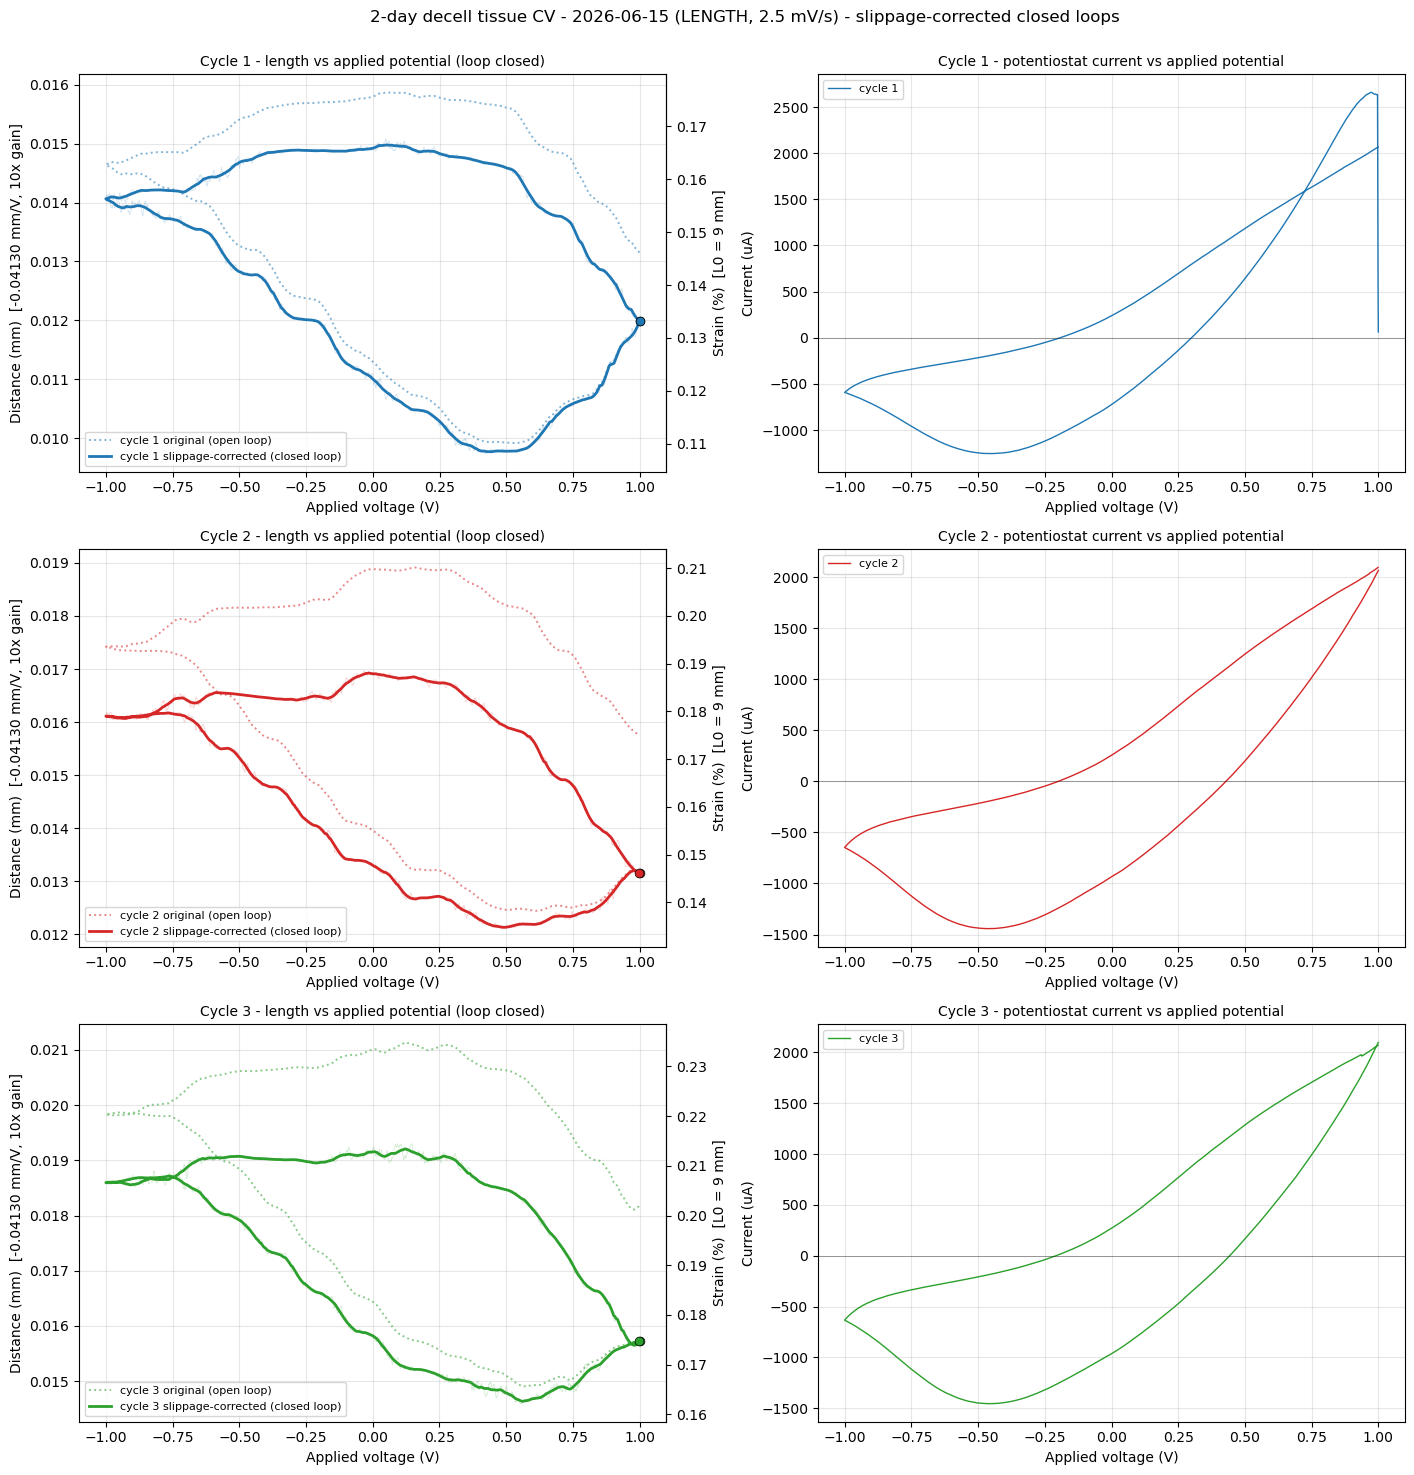

Distance conversion: -0.04130 mm per scope-V


In [2]:
# Plot: rows = cycles, columns = (length vs applied voltage, potentiostat current vs voltage).
# Each cycle sweeps +1 V -> -1 V -> +1 V and returns to its start, so absent slippage the length
# loop should CLOSE. We remove a per-cycle linear-in-time drift (grip creep / settling) so each
# cycle's start-+1 V == end-+1 V, and draw the original (open) loop dotted behind the closed one.

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- Sample geometry / calibration (LENGTH) ---
# length = -0.4130 mm/V at 1x gain; this run was captured at 10x gain (see header markdown),
# so 1 V corresponds to 1/10 the distance -> coefficient -0.4130/10 = -0.04130 mm/V.
LENGTH_COEF_MM_PER_V = -0.4130 / 10.0   # -0.04130 mm/V (10x gain)
L0_MM = 9                              # original length along actuation axis (for strain)
STRAIN_PER_V = LENGTH_COEF_MM_PER_V / L0_MM   # (mm/mm) per scope-V (used by slippage cells below)
def mm_to_strain(d): return d / L0_MM * 100.0     # percent strain
def strain_to_mm(s): return s * L0_MM / 100.0

PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
SMOOTH_WINDOW, SAVGOL_POLY, RAW_ALPHA = 101, 3, 0.20


def savgol_per_cycle(df, value_col, window=101, poly=3):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        y = sub[value_col].values
        n = len(y)
        if n < 3:
            out.loc[sub.index] = y
            continue
        w = min(window, n)
        if w % 2 == 0:
            w -= 1
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out


def close_loop_per_cycle(df, value_col, smooth_col):
    """Subtract a per-cycle linear-in-time drift so each cycle's last smoothed sample
    equals its first -- i.e. length(end-+1 V) == length(start-+1 V), closing the loop."""
    out = df[value_col].astype(float).copy()
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        t = sub['t_exp'].values
        y = sub[smooth_col].values
        if len(sub) < 2 or t[-1] == t[0]:
            continue
        slope = (y[-1] - y[0]) / (t[-1] - t[0])
        out.loc[sub.index] = df.loc[sub.index, value_col].values - slope * (t - t[0])
    return out


# Distance in mm, smoothed, and the closed-loop (creep/slippage-corrected) version.
scope_clean['dist_mm']       = scope_clean[SCOPE_CHANNEL] * LENGTH_COEF_MM_PER_V
scope_clean['smooth']        = savgol_per_cycle(scope_clean, 'dist_mm', SMOOTH_WINDOW, SAVGOL_POLY)
scope_clean['dist_closed']   = close_loop_per_cycle(scope_clean, 'dist_mm', 'smooth')
scope_clean['smooth_closed'] = savgol_per_cycle(scope_clean, 'dist_closed', SMOOTH_WINDOW, SAVGOL_POLY)

print('Per-cycle loop-closure gap (mm), end - start of smoothed length:')
for c in range(n_scans):
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')
    g0 = sub['smooth'].values[-1]        - sub['smooth'].values[0]
    g1 = sub['smooth_closed'].values[-1] - sub['smooth_closed'].values[0]
    print(f'  cycle {c+1}: before = {g0:+8.5f} mm   ->   after = {g1:+8.5f} mm')

fig, axes = plt.subplots(n_scans, 2, figsize=(15, 5*n_scans), squeeze=False)
for c in range(n_scans):
    color = PALETTE[c % len(PALETTE)]
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')

    # --- left: length vs applied voltage, closed loop (solid) over original (dotted) ---
    ax = axes[c, 0]
    ax.plot(sub['v_applied'], sub['smooth'], color=color, lw=1.4, ls=':', alpha=0.55,
            label=f'cycle {c+1} original (open loop)')
    ax.plot(sub['v_applied'], sub['dist_closed'], color=color, lw=0.6, alpha=RAW_ALPHA)
    ax.plot(sub['v_applied'], sub['smooth_closed'], color=color, lw=2.0,
            label=f'cycle {c+1} slippage-corrected (closed loop)')
    ax.scatter([sub['v_applied'].values[0], sub['v_applied'].values[-1]],
               [sub['smooth_closed'].values[0], sub['smooth_closed'].values[-1]],
               color=color, zorder=5, s=40, ec='k', lw=0.5)
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel(f'Distance (mm)  [{LENGTH_COEF_MM_PER_V:.5f} mm/V, 10x gain]')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax_st = ax.secondary_yaxis('right', functions=(mm_to_strain, strain_to_mm))
    ax_st.set_ylabel(f'Strain (%)  [L0 = {L0_MM} mm]')
    ax.set_title(f'Cycle {c+1} - length vs applied potential (loop closed)', fontsize=10)

    # --- right: potentiostat current ---
    axc = axes[c, 1]
    axc.plot(poten[f'v{c+1}'], poten[f'i{c+1}_uA'], color=color, lw=1.0, label=f'cycle {c+1}')
    axc.set_xlabel('Applied voltage (V)')
    axc.set_ylabel('Current (uA)')
    axc.axhline(0, color='k', lw=0.5, alpha=0.5)
    axc.grid(True, alpha=0.3)
    axc.legend(loc='best', fontsize=8)
    axc.set_title(f'Cycle {c+1} - potentiostat current vs applied potential', fontsize=10)

fig.suptitle('2-day decell tissue CV - 2026-06-15 (LENGTH, 2.5 mV/s) - slippage-corrected closed loops',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()
print(f'Distance conversion: {LENGTH_COEF_MM_PER_V:.5f} mm per scope-V')


## Linear slippage correction

Each scan starts and ends at **+1.0 V**, so the length at the top of the ramp should be the
same at the start and end of every cycle. The observed drop from start-+1 V to end-+1 V is
mechanical **slippage** of the sample in the grips (creep / settling), not real actuation.

We model it as a single **linear drift in time**: fit `length = a + b·t` through the
top-of-scan reference samples (`v_applied >= V_TOP`), then subtract `b·(t - t0)` from the whole
record. With a true linear drift removed, each cycle's start-+1 V and end-+1 V points line up.


Top-of-scan reference samples (v_applied >= 0.98): 97
Slippage rate:  -3.297e-05 V/s   ->   1.361e-06 mm/s
Total drift over 4801 s:  -0.1583 V   (0.0065 mm)


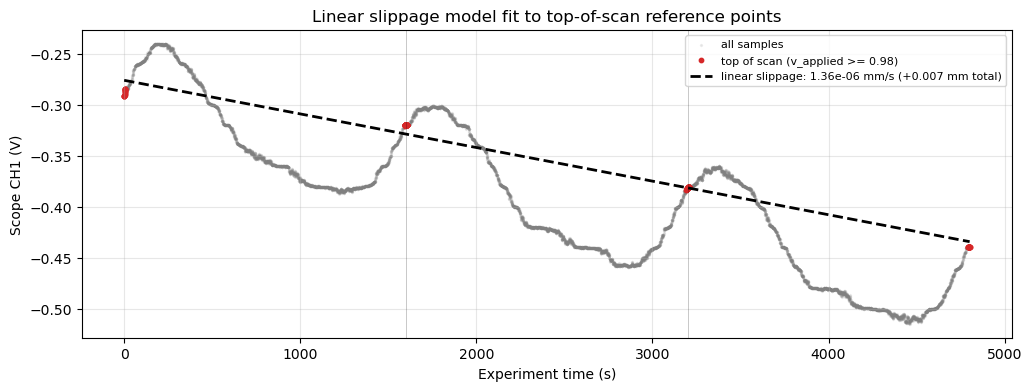

In [3]:
# ---- Fit the linear slippage to the top-of-scan (+1 V) reference points ----
# At v_applied ~ +1 V the "true" length should be constant across the whole run, so any
# linear trend in the scope signal at those points is pure slippage. Fit it globally.

V_TOP = 0.98   # samples at/above this applied voltage are "top of scan" reference points

t0 = scope_clean['t_exp'].min()
top = scope_clean[scope_clean['v_applied'] >= V_TOP]
b, a = np.polyfit(top['t_exp'].values, top[SCOPE_CHANNEL].values, 1)   # length(V) ~ a + b*t

span_s = scope_clean['t_exp'].max() - t0
drift_V = b * span_s
print(f'Top-of-scan reference samples (v_applied >= {V_TOP}): {len(top)}')
print(f'Slippage rate:  {b:.3e} V/s   ->   {b*LENGTH_COEF_MM_PER_V:.3e} mm/s')
print(f'Total drift over {span_s:.0f} s:  {drift_V:.4f} V   '
      f'({drift_V*LENGTH_COEF_MM_PER_V:.4f} mm)')

# Subtract the linear trend (anchored at t0 so the absolute level is preserved at start).
scope_clean['corrected'] = scope_clean[SCOPE_CHANNEL] - b * (scope_clean['t_exp'] - t0)

# Visualize the fit: full signal vs time, the reference points, and the fitted slippage line.
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(scope_clean['t_exp'], scope_clean[SCOPE_CHANNEL], s=2, alpha=0.12,
           color='gray', label='all samples')
ax.scatter(top['t_exp'], top[SCOPE_CHANNEL], s=10, color='#d62728',
           label=f'top of scan (v_applied >= {V_TOP})')
tt = np.array([t0, scope_clean['t_exp'].max()])
ax.plot(tt, a + b*tt, 'k--', lw=2,
        label=f'linear slippage: {b*LENGTH_COEF_MM_PER_V:.2e} mm/s ({drift_V*LENGTH_COEF_MM_PER_V:+.3f} mm total)')
for c in range(1, n_scans):
    ax.axvline(c*per_scan_s, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel('Experiment time (s)')
ax.set_ylabel('Scope CH1 (V)')
ax.set_title('Linear slippage model fit to top-of-scan reference points')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()


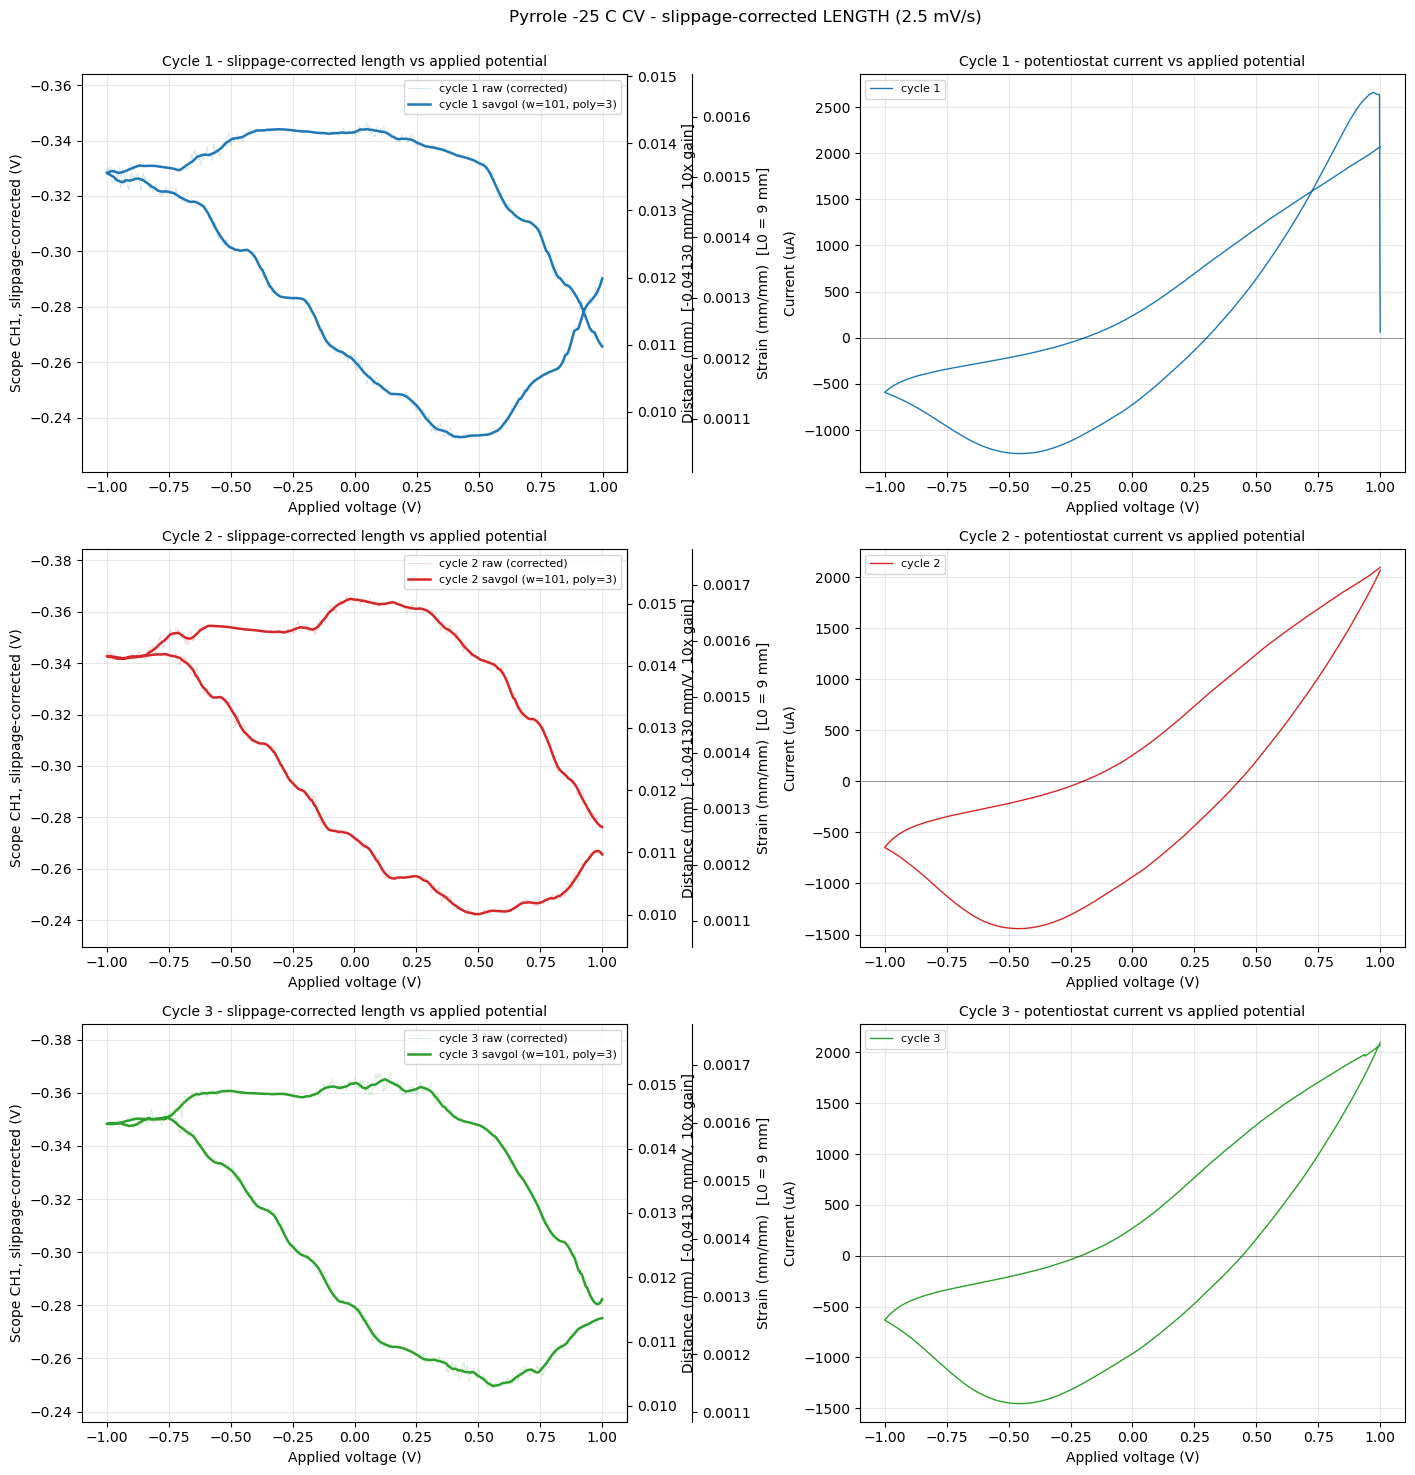

In [4]:
# ---- Replot the CV curves using the slippage-corrected length ----
# Same layout as the raw plot above, but the left panels now use the detrended signal so each
# cycle's start-+1 V and end-+1 V line up. Read the swing as the real actuation.

scope_clean['smooth_corr'] = savgol_per_cycle(scope_clean, 'corrected', SMOOTH_WINDOW, SAVGOL_POLY)

fig, axes = plt.subplots(n_scans, 2, figsize=(15, 5*n_scans), squeeze=False)
for c in range(n_scans):
    color = PALETTE[c % len(PALETTE)]
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')

    # --- left: slippage-corrected scope voltage with distance + strain secondary axes ---
    ax = axes[c, 0]
    ax.plot(sub['v_applied'], sub['corrected'], color=color, lw=0.6, alpha=RAW_ALPHA,
            label=f'cycle {c+1} raw (corrected)')
    ax.plot(sub['v_applied'], sub['smooth_corr'], color=color, lw=1.8,
            label=f'cycle {c+1} savgol (w={SMOOTH_WINDOW}, poly={SAVGOL_POLY})')
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel('Scope CH1, slippage-corrected (V)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax_d = ax.secondary_yaxis('right',
        functions=(lambda v: v*LENGTH_COEF_MM_PER_V, lambda d: d/LENGTH_COEF_MM_PER_V))
    ax_d.set_ylabel(f'Distance (mm)  [{LENGTH_COEF_MM_PER_V:.5f} mm/V, 10x gain]')
    ax_st = ax.secondary_yaxis(1.12,
        functions=(lambda v: v*STRAIN_PER_V, lambda st: st/STRAIN_PER_V))
    ax_st.set_ylabel(f'Strain (mm/mm)  [L0 = {L0_MM} mm]')
    # Pin the strain floor at 0: strain = 0 <-> scope_V = 0, so make scope_V = 0 the bottom
    # bound. strain is proportional to -scope_V, so the scope-V axis ends up inverted and
    # strain increases upward from 0. Top bound = most-negative scope_V (max strain) + headroom.
    ax.set_ylim(sub['corrected'].max() - 0.05 * sub['corrected'].max() , sub['corrected'].min() + 0.05 * sub['corrected'].min())
    ax.set_title(f'Cycle {c+1} - slippage-corrected length vs applied potential', fontsize=10)

    # --- right: potentiostat current (unchanged) ---
    axc = axes[c, 1]
    axc.plot(poten[f'v{c+1}'], poten[f'i{c+1}_uA'], color=color, lw=1.0, label=f'cycle {c+1}')
    axc.set_xlabel('Applied voltage (V)')
    axc.set_ylabel('Current (uA)')
    axc.axhline(0, color='k', lw=0.5, alpha=0.5)
    axc.grid(True, alpha=0.3)
    axc.legend(loc='best', fontsize=8)
    axc.set_title(f'Cycle {c+1} - potentiostat current vs applied potential', fontsize=10)

fig.suptitle('Pyrrole -25 C CV - slippage-corrected LENGTH (2.5 mV/s)', fontsize=12)
fig.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()
